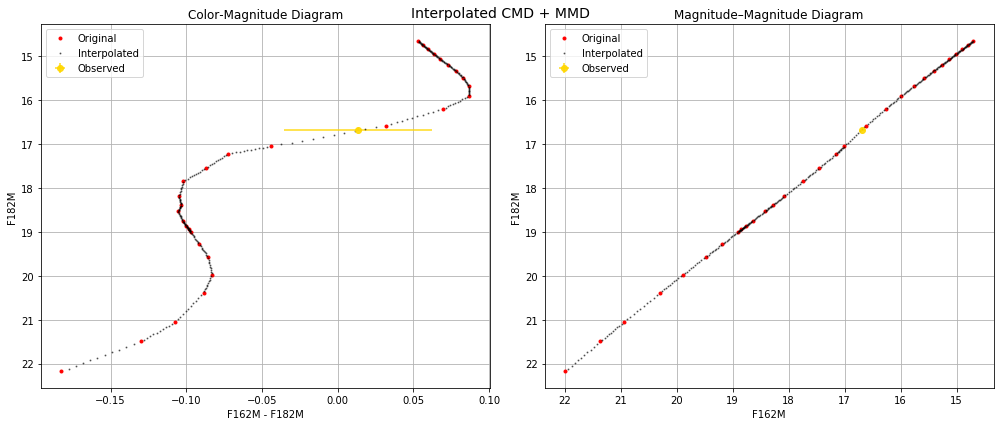

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from spisea import synthetic, evolution, atmospheres, reddening
from matplotlib.colors import LogNorm
import csv
from scipy.stats import chi2

# === Setup ===
iso_dir = 'isochrones/'
output_dir = 'output_diagrams/'
os.makedirs(output_dir, exist_ok=True)

# --- Static Parameters ---
star_index = 0
dist = 4500
metallicity = 0
log_age_arr = np.log10([1e6])  # 1 Myr

# Models
evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawCardelli(3.1)

# Filters
filt_list = ['jwst,F162M', 'jwst,F182M', 'jwst,F200W']
filters = ['m_jwst_F162M', 'm_jwst_F182M', 'm_jwst_F200W']

filter_wavelengths = {
    "m_jwst_F162M": 1.62,
    "m_jwst_F182M": 1.82,
    "m_jwst_F200W": 2.00,
    "m_jwst_F356M": 3.56,
    "m_jwst_F405N": 4.05
}

# --- Load star data ---
def load_star_data(csv_path, index=0):
    sample_mags, sample_errs = [], []
    with open(csv_path, mode='r') as file:
        reader = csv.reader(file)
        next(reader)
        for line in reader:
            mags = [float(line[i]) for i in range(1, len(line), 2)]
            errs = [float(line[i]) for i in range(2, len(line), 2)]
            sample_mags.append(mags)
            sample_errs.append(errs)
    return sample_mags[index][:3], sample_errs[index][:3]  # Include F200W

# --- Interpolate Isochrone Points ---
def interpolate_isochrone(isochrone, num_interp=10):
    masses = isochrone.points['mass']
    m1 = isochrone.points['m_jwst_F162M']
    m2 = isochrone.points['m_jwst_F182M']
    m3 = isochrone.points['m_jwst_F200W']

    # Collect original + interpolated points
    interp_data = []

    for i in range(len(masses) - 1):
        mass1, mass2 = masses[i], masses[i+1]
        m1_1, m1_2 = m1[i], m1[i+1]
        m2_1, m2_2 = m2[i], m2[i+1]
        m3_1, m3_2 = m3[i], m3[i+1]

        # Interpolate mass values
        interp_masses = np.linspace(mass1, mass2, num=num_interp+2)[1:-1]
        interp_m1 = np.linspace(m1_1, m1_2, num=num_interp+2)[1:-1]
        interp_m2 = np.linspace(m2_1, m2_2, num=num_interp+2)[1:-1]
        interp_m3 = np.linspace(m3_1, m3_2, num=num_interp+2)[1:-1]

        for m, im1, im2, im3 in zip(interp_masses, interp_m1, interp_m2, interp_m3):
            interp_data.append((m, im1, im2, im3, False))  # False = interpolated

    # Add original points
    for i in range(len(masses)):
        interp_data.append((masses[i], m1[i], m2[i], m3[i], True))  # True = original

    # Convert to structured array
    interp_data = sorted(interp_data, key=lambda x: x[0])
    dtype = [('mass', float), ('m_jwst_F162M', float), ('m_jwst_F182M', float), ('m_jwst_F200W', float), ('is_original', bool)]
    interp_array = np.array(interp_data, dtype=dtype)
    return interp_array

# --- Apply Dereddening ---
def apply_dereddening(mags, AKs, wavelengths):
    return [
        m - red_law.Cardelli89(wavelengths[filters[i]], AKs)
        for i, m in enumerate(mags)
    ]

# --- Compute Errors ---
def calculate_errors(errs):
    color_err = np.sqrt(errs[0]**2 + errs[1]**2)
    mag_err = errs[1]
    return color_err, mag_err

# --- Plotting Function ---
def plot_cmd_and_mmd(interp_table, dered_mags, errors, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    ax_cmd, ax_mmd = axes
    m162_d, m182_d, _ = dered_mags
    color_err, mag_err = errors

    # Split by origin
    original = interp_table[interp_table['is_original']]
    interp = interp_table[~interp_table['is_original']]

    # === Color-Magnitude Diagram (CMD) ===
    colors_orig = original['m_jwst_F162M'] - original['m_jwst_F182M']
    mags_orig = original['m_jwst_F182M']
    colors_interp = interp['m_jwst_F162M'] - interp['m_jwst_F182M']
    mags_interp = interp['m_jwst_F182M']

    ax_cmd.plot(colors_orig, mags_orig, 'ro', markersize=3, label='Original')
    ax_cmd.plot(colors_interp, mags_interp, 'k.', markersize=2, alpha=0.5, label='Interpolated')
    ax_cmd.errorbar(m162_d - m182_d, m182_d, xerr=color_err, yerr=mag_err,
                    fmt='o', color='gold', alpha=0.9, label='Observed')

    ax_cmd.set_xlabel("F162M - F182M")
    ax_cmd.set_ylabel("F182M")
    ax_cmd.invert_yaxis()
    ax_cmd.set_title("Color-Magnitude Diagram")
    ax_cmd.grid(True)
    ax_cmd.legend()

    # === Magnitude-Magnitude Diagram (MMD) ===
    ax_mmd.plot(original['m_jwst_F162M'], original['m_jwst_F182M'], 'ro', markersize=3, label='Original')
    ax_mmd.plot(interp['m_jwst_F162M'], interp['m_jwst_F182M'], 'k.', markersize=2, alpha=0.5, label='Interpolated')
    ax_mmd.errorbar(m162_d, m182_d, xerr=errs[0], yerr=errs[1],
                    fmt='o', color='gold', alpha=0.9, label='Observed')

    ax_mmd.set_xlabel("F162M")
    ax_mmd.set_ylabel("F182M")
    ax_mmd.invert_yaxis()
    ax_mmd.invert_xaxis()
    ax_mmd.set_title("Magnitude–Magnitude Diagram")
    ax_mmd.grid(True)
    ax_mmd.legend()

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# === Main Execution ===
csv_path = '/scratch/wyz5rge/synthetic-hr/notebooks/2025/01-28_chi-square-reverse-modeling/s284.csv'
mags, errs = load_star_data(csv_path, star_index)
AKs_val = 0.88

# Deredden
dered_mags = apply_dereddening(mags, AKs_val, filter_wavelengths)
errors = calculate_errors(errs)

# Generate isochrone and interpolate
iso = synthetic.IsochronePhot(log_age_arr[0], AKs=0.0, distance=dist,
                               metallicity=metallicity,
                               evo_model=evo_model, atm_func=atm_func,
                               red_law=red_law, filters=filt_list,
                               iso_dir=iso_dir)

interp_table = interpolate_isochrone(iso, num_interp=10)

# Plot CMD
plot_cmd_and_mmd(interp_table, dered_mags, errors, "Interpolated CMD + MMD")

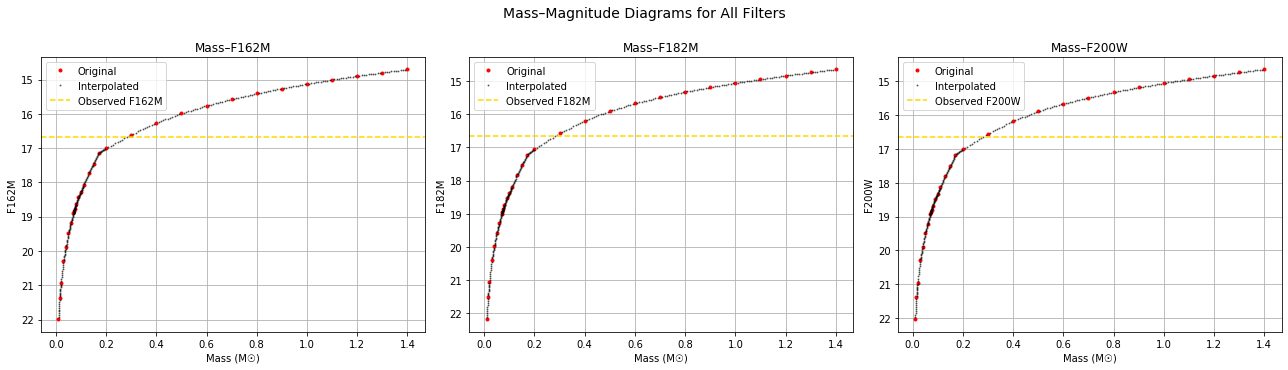

In [5]:
# === Mass–Magnitude Diagrams for F162M, F182M, F200W ===
def plot_mass_diagrams_all_filters(interp_table, dered_mags, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ax_f162m, ax_f182m, ax_f200w = axes
    m162_d, m182_d, m200_d = dered_mags

    # Split by origin
    original = interp_table[interp_table['is_original']]
    interp = interp_table[~interp_table['is_original']]

    # --- Mass vs F162M ---
    ax_f162m.plot(original['mass'], original['m_jwst_F162M'], 'ro', markersize=3, label='Original')
    ax_f162m.plot(interp['mass'], interp['m_jwst_F162M'], 'k.', markersize=2, alpha=0.5, label='Interpolated')
    ax_f162m.axhline(m162_d, color='gold', linestyle='--', label='Observed F162M')
    ax_f162m.set_xlabel("Mass (M☉)")
    ax_f162m.set_ylabel("F162M")
    ax_f162m.set_title("Mass–F162M")
    ax_f162m.invert_yaxis()
    ax_f162m.grid(True)
    ax_f162m.legend()

    # --- Mass vs F182M ---
    ax_f182m.plot(original['mass'], original['m_jwst_F182M'], 'ro', markersize=3, label='Original')
    ax_f182m.plot(interp['mass'], interp['m_jwst_F182M'], 'k.', markersize=2, alpha=0.5, label='Interpolated')
    ax_f182m.axhline(m182_d, color='gold', linestyle='--', label='Observed F182M')
    ax_f182m.set_xlabel("Mass (M☉)")
    ax_f182m.set_ylabel("F182M")
    ax_f182m.set_title("Mass–F182M")
    ax_f182m.invert_yaxis()
    ax_f182m.grid(True)
    ax_f182m.legend()

    # --- Mass vs F200W ---
    ax_f200w.plot(original['mass'], original['m_jwst_F200W'], 'ro', markersize=3, label='Original')
    ax_f200w.plot(interp['mass'], interp['m_jwst_F200W'], 'k.', markersize=2, alpha=0.5, label='Interpolated')
    ax_f200w.axhline(m200_d, color='gold', linestyle='--', label='Observed F200W')
    ax_f200w.set_xlabel("Mass (M☉)")
    ax_f200w.set_ylabel("F200W")
    ax_f200w.set_title("Mass–F200W")
    ax_f200w.invert_yaxis()
    ax_f200w.grid(True)
    ax_f200w.legend()

    fig.suptitle(title, fontsize=14, y=1.02)  # Move title up
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)  # Give space for suptitle
    plt.show()

# Call the function
plot_mass_diagrams_all_filters(interp_table, dered_mags, "Mass–Magnitude Diagrams for All Filters")

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
cmap = plt.get_cmap("coolwarm")

# Plot Color-Magnitude Diagram (CMD)
for i, instance in enumerate(isochrone_AKs_00):
    ax1.plot(instance.points["m_jwst_F162M"] - instance.points["m_jwst_F182M"],
             instance.points["m_jwst_F182M"], color="r", linestyle="none", marker='o')

for i, (m162_d, m182_d) in enumerate(dereddened_mags):
    ax1.errorbar(m162_d - m182_d, m182_d, xerr=color_err, yerr=mag_err,
                 fmt='o', color='gold', alpha=0.7)

ax1.set_xlabel("F162M - F182M")
ax1.set_ylabel("F182M")
ax1.invert_yaxis()
ax1.grid(True)
ax1.set_title("Color-Magnitude Diagram")

# Plot Magnitude-Magnitude Diagram (MMD)
for i, instance in enumerate(isochrone_AKs_00):
    # color = cmap(i / (len(isochrone_grid) - 1))
    # ax2.plot(instance.points["m_jwst_F162M"], instance.points["m_jwst_F182M"], color=color)
    ax2.plot(instance.points["m_jwst_F162M"], instance.points["m_jwst_F182M"], color="r", linestyle="none", marker='o')

for i, (m162_d, m182_d) in enumerate(dereddened_mags):
    ax2.errorbar(m162_d, m182_d, xerr=color_err, yerr=mag_err,
                 fmt='o', color='gold', alpha=0.7)

ax2.set_xlabel("F162M")
ax2.set_ylabel("F182M")
ax2.invert_xaxis()
ax2.invert_yaxis()
ax2.grid(True)
ax2.set_title("Magnitude-Magnitude Diagram")

plt.show()

In [ ]:
# Load sample magnitudes and errors
sample_mags, sample_errors = [], []

with open('/scratch/wyz5rge/synthetic-hr/notebooks/2025/01-28_chi-square-reverse-modeling/s284.csv', mode='r') as file:
    csvFile = csv.reader(file)
    next(csvFile)  # Skip header row
    for line in csvFile:
        sample_mags.append([float(line[1]), float(line[3]), float(line[5])])  # Extract F162M, F182M, F200W
        sample_errors.append([float(line[2]), float(line[4]), float(line[6])])  # Extract corresponding errors

sample_mags = np.array(sample_mags)
sample_errors = np.array(sample_errors)

# Chi-square function accounting for errors
def chi_square_with_errors(iso_grid, obs_mags, obs_errors):
    DOF = len(obs_mags) - 1  # Degrees of freedom: num filters - 1
    chi_square_values = []
    mass_values = []
    
    for iso in iso_grid:
        for star in iso.points:
            chi_sq = sum(
                ((obs_mags[k] - star[filters[k]]) ** 2) / max(obs_errors[k] ** 2, 1e-3)  # Avoid zero division
                for k in range(len(obs_mags))
            ) / DOF  # Compute reduced chi-square
            chi_square_values.append(chi_sq)
            mass_values.append(star['mass'])
    
    return np.array(mass_values), np.array(chi_square_values)

all_masses = []
all_chi_squares = []

for AKs in AKs_values:
    # Generate isochrone grid
    instances = np.array([
        synthetic.IsochronePhot(log_age_arr[0], AKs, dist, metallicity=metallicity,
                                evo_model=evo_model, atm_func=atm_func,
                                red_law=red_law, filters=filt_list,
                                iso_dir=iso_dir)
    ])
    
    # Compute chi-square values
    masses, chi_squares = chi_square_with_errors(instances, sample_mags[0], sample_errors[0])
    all_masses.extend(masses)
    all_chi_squares.extend(chi_squares)

# Convert to arrays
all_masses = np.array(all_masses)
all_chi_squares = np.array(all_chi_squares)
all_AKs = np.repeat(AKs_values, len(instances[0].points))

# Plotting
fig, ax = plt.subplots(figsize=(10, 8))
norm = LogNorm(vmin=max(np.min(all_chi_squares), 1e-3), vmax=np.max(all_chi_squares))
cmap = plt.get_cmap('coolwarm')

# Scatter plot with chi-square gradient
sc = ax.scatter(
    all_AKs, all_masses, c=all_chi_squares, cmap=cmap, norm=norm, s=50, edgecolor='k', linewidth=0.5
)

# Highlight low chi-square points
df = len(filters) - 1
critical_value = chi2.ppf(0.95, df) / df
low_chi_mask = all_chi_squares < critical_value
ax.scatter(
    all_AKs[low_chi_mask], all_masses[low_chi_mask], c='gold', edgecolor='black',
    s=120, marker='*', label=fr'$\chi^2 <$ {critical_value:.3f}'
)

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Chi-Squared Value')

# Labels and styling
ax.set_xlabel('AKs Extinction')
ax.set_ylabel('Mass (M☉)')
ax.set_yscale('log')

# Set y-limits just below lowest point
bottom_mass = np.min(all_masses)
ax.set_ylim(bottom_mass * 0.9, np.max(all_masses) * 1.05)

ax.set_title('Mass vs AKs with Chi-Squared Coloring')
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()


In [ ]:
# Identify the 10 smallest chi-squared values and their indices
top_n = 10
smallest_indices = np.argsort(all_chi_squares)[:top_n]

print(f"Top {top_n} smallest chi-squared fits:")
print(f"{'Index':<5} {'Chi^2':<10} {'Mass (M☉)':<12} {'AKs':<6}")
print("-" * 40)

for i, idx in enumerate(smallest_indices):
    chi2_val = all_chi_squares[idx]
    mass_val = all_masses[idx]
    aks_val = all_AKs[idx]
    print(f"{i:<5} {chi2_val:<10.4f} {mass_val:<12.4f} {aks_val:<6.2f}")